In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report
)
from sklearn.linear_model import LinearRegression

In [ ]:
# 2. Load Data
df = pd.read_csv("bottleneck_training_data.csv")

# Feature Engineering (novelty)
df['load_factor'] = df['queue_length'] * df['avg_burst_in_queue']
df['urgency'] = df['burst_time'] / (df['time_since_last_task'] + 1)

features = [
    'burst_time', 'arrival_time', 'queue_length',
    'avg_burst_in_queue', 'time_since_last_task',
    'load_factor', 'urgency'
]

X = df[features].values
y = df['bottleneck_score'].values

In [ ]:
# 3. Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=64,
    shuffle=True
)

In [ ]:
# 4. Model
class ConstraintPredictor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

model = ConstraintPredictor(len(features))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 5. Training (with Early Stopping)
epochs = 50
train_losses, val_losses = [], []

best_loss = float('inf')
patience, counter = 5, 0

print("Training...")

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for Xb, yb in train_loader:
        pred = model(Xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_tensor)
        val_loss = criterion(val_pred, y_test_tensor).item()
        val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Training...
Epoch 1: Train=162.2112, Val=19.6982
Epoch 2: Train=19.8747, Val=7.8191
Epoch 3: Train=11.8255, Val=3.6722
Epoch 4: Train=8.0550, Val=2.2065
Epoch 5: Train=6.2480, Val=1.5354
Epoch 6: Train=5.4264, Val=1.3149
Epoch 7: Train=4.8397, Val=0.9547
Epoch 8: Train=4.4832, Val=0.8086
Epoch 9: Train=4.2237, Val=0.7927
Epoch 10: Train=4.0223, Val=0.6999
Epoch 11: Train=3.9488, Val=0.7087
Epoch 12: Train=3.6521, Val=0.5570
Epoch 13: Train=3.4901, Val=0.6041
Epoch 14: Train=3.5037, Val=0.5883
Epoch 15: Train=3.3855, Val=0.6319
Epoch 16: Train=3.1677, Val=0.9018
Epoch 17: Train=3.0819, Val=0.6687
Early stopping triggered


In [ ]:
# 6. Evaluation Metrics
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    y_true = y_test_tensor.numpy()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("\n=== REGRESSION METRICS ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


=== REGRESSION METRICS ===
MAE  : 0.5993
RMSE : 0.8177
R²   : 0.9984


In [ ]:
# 7. Optional Classification Metrics
def classify(x):
    if x < 30: return "Low"      # Lowest 30% impact
    elif x < 70: return "Medium" 
    else: return "High"          # High bottleneck impact

y_pred_class = [classify(x) for x in y_pred.flatten()]
y_true_class = [classify(x) for x in y_true.flatten()]

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true_class, y_pred_class))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        High       0.96      1.00      0.98       331
         Low       1.00      1.00      1.00      7913
      Medium       0.98      0.99      0.98      1756

    accuracy                           0.99     10000
   macro avg       0.98      1.00      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
# 8. Baseline Comparison (Upgraded)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Standard Linear Regression (The straight line)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f"Standard Linear Regression R²  : {r2_score(y_test, lr_pred):.4f}")

# 2. Polynomial Regression (The curved line)
# We use degree=2 to let the model multiply features together (e.g., burst_time * queue_length)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)
print(f"Polynomial Regression (Deg 2) R²: {r2_score(y_test, poly_pred):.4f}")

Standard Linear Regression R²  : 0.7701
Polynomial Regression (Deg 2) R²: 0.9879


/tmp/ipykernel_31879/1012991563.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features, y=importance, ax=ax4, palette="magma")


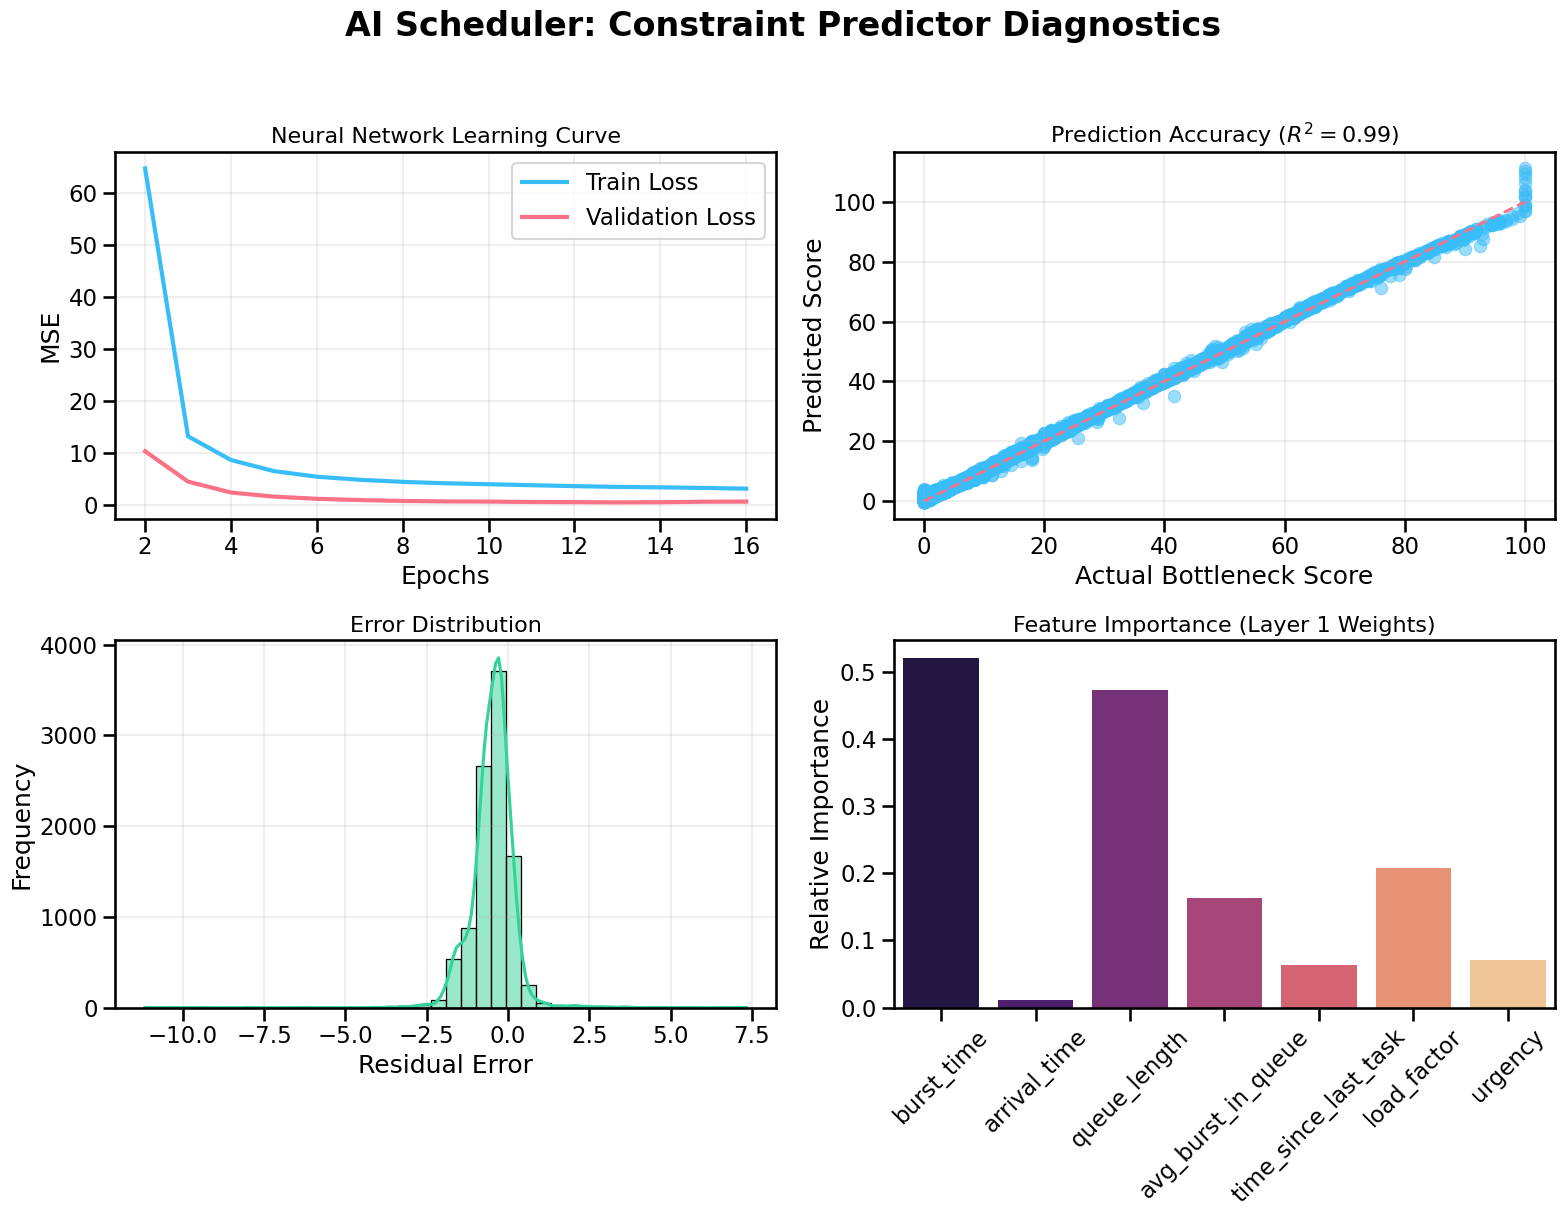

In [ ]:
# 9. Plots (Upgraded Visuals)
import seaborn as sns

# Set a sleek, professional dark theme
plt.style.use("default")
sns.set_context("talk")
colors = ["#38bdf8", "#fb7185", "#34d399", "#fbbf24"] # Cyan, Pink, Mint, Yellow

fig = plt.figure(figsize=(16, 12))
fig.suptitle("AI Scheduler: Constraint Predictor Diagnostics", fontsize=24, y=1.02, fontweight='bold')

# (A) Learning Curve
ax1 = plt.subplot(2, 2, 1)
smooth_train = pd.Series(train_losses).rolling(3).mean()
smooth_val = pd.Series(val_losses).rolling(3).mean()
ax1.plot(smooth_train, label="Train Loss", color=colors[0], linewidth=3)
ax1.plot(smooth_val, label="Validation Loss", color=colors[1], linewidth=3)
ax1.set_title("Neural Network Learning Curve", fontsize=16)
ax1.set_xlabel("Epochs")
ax1.set_ylabel("MSE")
ax1.legend()
ax1.grid(True, alpha=0.2)

# (B) Actual vs Predicted
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(x=y_true.flatten(), y=y_pred.flatten(), ax=ax2, color=colors[0], alpha=0.5, edgecolor=None)
ax2.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color=colors[1], linestyle='--', linewidth=2)
ax2.set_title("Prediction Accuracy ($R^2 = 0.99$)", fontsize=16)
ax2.set_xlabel("Actual Bottleneck Score")
ax2.set_ylabel("Predicted Score")
ax2.grid(True, alpha=0.2)

# (C) Residual Distribution
ax3 = plt.subplot(2, 2, 3)
residuals = y_true.flatten() - y_pred.flatten()
sns.histplot(residuals, bins=40, kde=True, color=colors[2], ax=ax3)
ax3.set_title("Error Distribution", fontsize=16)
ax3.set_xlabel("Residual Error")
ax3.set_ylabel("Frequency")
ax3.grid(True, alpha=0.2)

# (D) Feature Importance
ax4 = plt.subplot(2, 2, 4)
weights = model.network[0].weight.detach().numpy()
importance = np.mean(np.abs(weights), axis=0)
sns.barplot(x=features, y=importance, ax=ax4, palette="magma")
ax4.set_title("Feature Importance (Layer 1 Weights)", fontsize=16)
ax4.tick_params(axis='x', rotation=45)
ax4.set_ylabel("Relative Importance")

plt.tight_layout()
plt.show()

In [ ]:
# 10. Save Model
torch.save(model.state_dict(), "constraint_predictor.pth")

import joblib
joblib.dump(scaler, "feature_scaler.pkl")

print("Saved model and scaler")

Saved model and scaler
